#Task 5: Custom Batch Normalization and Layer Normalization Forward/Backward Propagation
#Objective:
 Maximize training convergence speeds and stabilize internal covariate shifts by
building structural normalization layers with manual gradient derivations.
#Required Tech Stack:
 PyTorch (with Autograd disabled), NumPy.
#Task Description:
 Students must write functional modules for Batch Normalization and
Layer Normalization. They are required to derive and implement the forward passes
(calculating running mean and variance) and write the exact partial derivatives for
backpropagating gradients through the scale parameter , shift parameter , and
normalize transformations

Import Libraries

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

Create Dataset

In [2]:
X = torch.randn(256, 20)
Y = torch.randint(0, 2, (256,))

print(X.shape)

torch.Size([256, 20])


Initialize Parameters

In [3]:
gamma = torch.ones(20)
beta = torch.zeros(20)

eps = 1e-5

BatchNorm Forward

In [4]:
def batch_norm_forward(X, gamma, beta, eps=1e-5):

    mean = torch.mean(X, dim=0)

    var = torch.var(X, dim=0, unbiased=False)

    X_hat = (X - mean) / torch.sqrt(var + eps)

    out = gamma * X_hat + beta

    cache = (X, X_hat, mean, var, gamma, beta)

    return out, cache

LayerNorm Forward

In [5]:
def layer_norm_forward(X, gamma, beta, eps=1e-5):

    mean = torch.mean(X, dim=1, keepdim=True)

    var = torch.var(X, dim=1, unbiased=False, keepdim=True)

    X_hat = (X - mean) / torch.sqrt(var + eps)

    out = gamma * X_hat + beta

    cache = (X, X_hat, mean, var, gamma, beta)

    return out, cache

BatchNorm Backward

In [6]:
def batch_norm_backward(dout, cache, eps=1e-5):

    X, X_hat, mean, var, gamma, beta = cache

    N = X.shape[0]

    dgamma = torch.sum(dout * X_hat, dim=0)
    dbeta = torch.sum(dout, dim=0)

    dX_hat = dout * gamma

    inv_std = 1 / torch.sqrt(var + eps)

    dvar = torch.sum(
        dX_hat * (X - mean) * -0.5 * inv_std**3,
        dim=0
    )

    dmean = (
        torch.sum(-dX_hat * inv_std, dim=0)
        + dvar * torch.mean(-2 * (X - mean), dim=0)
    )

    dX = (
        dX_hat * inv_std
        + dvar * 2 * (X - mean) / N
        + dmean / N
    )

    return dX, dgamma, dbeta

LayerNorm Backward

In [7]:
def layer_norm_backward(dout, cache, eps=1e-5):

    X, X_hat, mean, var, gamma, beta = cache

    D = X.shape[1]

    dgamma = torch.sum(dout * X_hat, dim=0)
    dbeta = torch.sum(dout, dim=0)

    dX_hat = dout * gamma

    inv_std = 1 / torch.sqrt(var + eps)

    dvar = torch.sum(
        dX_hat * (X - mean) * -0.5 * inv_std**3,
        dim=1,
        keepdim=True
    )

    dmean = (
        torch.sum(-dX_hat * inv_std, dim=1, keepdim=True)
        + dvar * torch.mean(-2 * (X - mean), dim=1, keepdim=True)
    )

    dX = (
        dX_hat * inv_std
        + dvar * 2 * (X - mean) / D
        + dmean / D
    )

    return dX, dgamma, dbeta

Test Forward & Backward

In [8]:
bn_out, bn_cache = batch_norm_forward(X, gamma, beta)
ln_out, ln_cache = layer_norm_forward(X, gamma, beta)

dout = torch.randn_like(X)

bn_dx, bn_dgamma, bn_dbeta = batch_norm_backward(dout, bn_cache)
ln_dx, ln_dgamma, ln_dbeta = layer_norm_backward(dout, ln_cache)

Verify Shapes

In [9]:
print("BatchNorm Output:", bn_out.shape)
print("LayerNorm Output:", ln_out.shape)

print("BatchNorm dX:", bn_dx.shape)
print("LayerNorm dX:", ln_dx.shape)

print("Gamma Gradient:", bn_dgamma.shape)
print("Beta Gradient:", bn_dbeta.shape)

BatchNorm Output: torch.Size([256, 20])
LayerNorm Output: torch.Size([256, 20])
BatchNorm dX: torch.Size([256, 20])
LayerNorm dX: torch.Size([256, 20])
Gamma Gradient: torch.Size([20])
Beta Gradient: torch.Size([20])


Visualization

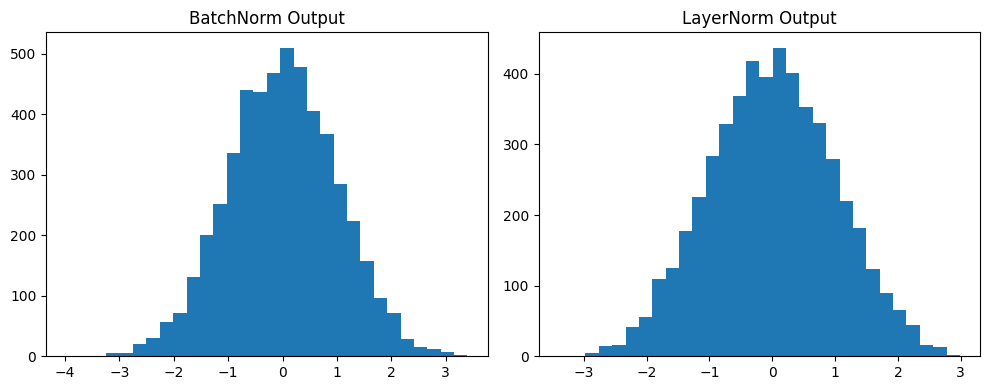

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(bn_out.flatten().numpy(), bins=30)
plt.title("BatchNorm Output")

plt.subplot(1,2,2)
plt.hist(ln_out.flatten().numpy(), bins=30)
plt.title("LayerNorm Output")

plt.tight_layout()
plt.show()